# GLMM to evaluate the factor that impact Predict and Variability

In this notebook, the ....

# Packages

In [3]:
packages <- list("lme4", "glmmTMB", "ggeffects")
for (pack in packages) {
    if (!requireNamespace(pack, quietly = TRUE)) {
      print(paste('Installing', pack))
      install.packages(pack)
    }
}

In [4]:
library(readr)
library(lme4)
library(glmmTMB)
library(ggplot2)
library(ggeffects)

Loading required package: Matrix



# Read Dataset

In [55]:
dataset_v0 = read_csv("data/dataset/ds_test_set_with_metrics.csv", show_col_types = FALSE)
head(dataset_v0)

tag,obs,gender,weight,thing_id,depth,partition,exp,interval,farm,⋯,w_pred,abse,mbse,sque,mape,qi,qi_train,qtt_in_train,farms,w_cv
<chr>,<lgl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
918,NA,1,33.45,Ahk7H4mnwdaJbN1FCxdR,918_15801_2025_01_26_09_09_16_063518_DEPTH_320_240_1.png,test,run-1,4,Farm A,⋯,38.87794,-5.427941,5.427941,29.462545,0.16227029,6127.043,4243.795,249,2,6.04843
918,NA,1,33.45,Ahk7H4mnwdaJbN1FCxdR,918_15803_2025_01_26_09_09_16_256934_DEPTH_320_240_1.png,test,run-1,4,Farm A,⋯,35.84887,-2.398866,2.398866,5.754556,0.07171496,5927.288,4243.795,249,2,6.04843
918,NA,1,33.45,Ahk7H4mnwdaJbN1FCxdR,918_15800_2025_01_26_09_09_15_945344_DEPTH_320_240_1.png,test,run-1,4,Farm A,⋯,38.28473,-4.834729,4.834729,23.374605,0.14453599,6006.308,4243.795,249,2,6.04843
918,NA,1,33.45,Ahk7H4mnwdaJbN1FCxdR,918_15799_2025_01_26_09_09_15_850842_DEPTH_320_240_1.png,test,run-1,4,Farm A,⋯,39.19309,-5.743089,5.743089,32.983066,0.17169173,6044.325,4243.795,249,2,6.04843
918,NA,1,33.45,Ahk7H4mnwdaJbN1FCxdR,918_15798_2025_01_26_09_09_15_738744_DEPTH_320_240_1.png,test,run-1,4,Farm A,⋯,42.99206,-9.542062,9.542062,91.050940,0.28526343,5979.602,4243.795,249,2,6.04843
918,NA,1,33.45,Ahk7H4mnwdaJbN1FCxdR,918_15802_2025_01_26_09_09_16_160990_DEPTH_320_240_1.png,test,run-1,4,Farm A,⋯,37.85247,-4.402474,4.402474,19.381779,0.13161358,5958.952,4243.795,249,2,6.04843


In [61]:
dataset_v0$farm  = as.factor(dataset_v0$farm)
dataset_v0$exp  = as.factor(dataset_v0$exp)
dataset_v0$thing_id = as.factor(dataset_v0$thing_id)
dataset_v0$farms = as.factor(dataset_v0$farms)

dim(dataset_v0)

[1] 1854   21

In [167]:
# Function to normalize a numeric vector to a 0-1 range
normalize <- function(x) {
  return((x - min(x, na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE)))
}

In [168]:
dataset_v0$train_size <- normalize(dataset_v0$train_size)
dataset_v0$qi_train <- normalize(dataset_v0$qi_train)
dataset_v0$qi <- normalize(dataset_v0$qi)
dataset_v0$qtt_in_train <- normalize(dataset_v0$qtt_in_train)
dataset_v0$weight <- normalize(dataset_v0$weight)

# Prediction Error Analysis

## Data Distribution
Analyze relative error distribution

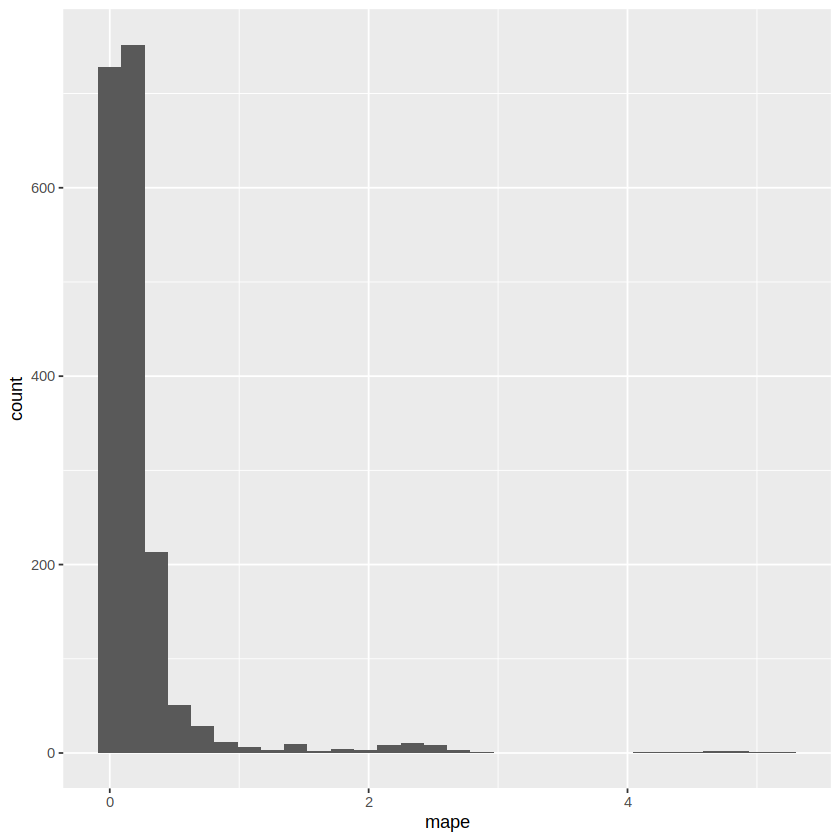

In [452]:
ggplot(dataset_v0, aes(x = mape)) + geom_histogram(bins = 30)

## Candidate Model #1

NOTES

2. Removi **train_size** porque é muito correlacionado com **farms**
3. O resultado piorou, então voltei train_size e removi farms. Faz mais sentido pq passa mais info...
4. As alterações mais para o lado dos dados de teste não são muito relevantes
5. ~~Um último com farms com factor pra testar se mostra diferença que justifique o run-5~~

### Adjust Models

In [151]:
modelA_1 <- lme4::glmer(
  "mape ~ train_size + qi_train + qtt_in_train + qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_1)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ farms + train_size + qi_train + qtt_in_train + qi + weight +  
    (1 | thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -3464.7  -3415.0   1741.4  -3482.7     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4903 -0.7004 -0.0386  0.5372  4.9647 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.2419   0.4918  
 Residual             0.4502   0.6710  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
             Estimate Std. Error t value Pr(>|z|)    
(Intercept)   -3.0137     0.3365  -8.955  < 2e-16 ***
farms2        -1.8273     0.2828  -6.462 1.04e-10 ***
train_size     2.5276     0.5166   4.893 9.92e-07 ***
qi_train       1.9737     0.3572   5.525 3.29e-08 ***
qtt_in_train   0.4277     0.2012   2.126   0.0335 *  
qi             0.4394     0.2360   1.862   0.062

In [389]:
modelA_2 <- lme4::glmer(
  "mape ~ train_size * qi_train + qtt_in_train + qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_2)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * qi_train + qtt_in_train + qi + weight + (1 |  
    thing_id)
   Data: dataset_v2

     AIC      BIC   logLik deviance df.resid 
 -3467.7  -3418.0   1742.9  -3485.7     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4891 -0.7058 -0.0390  0.5431  4.7671 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.2382   0.4881  
 Residual             0.4510   0.6715  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                    Estimate Std. Error t value Pr(>|z|)    
(Intercept)          -2.9971     0.3250  -9.223  < 2e-16 ***
train_size            2.5753     0.5055   5.095 3.49e-07 ***
qi_train              2.0292     0.3532   5.745 9.17e-09 ***
qtt_in_train          0.4076     0.2001   2.037   0.0416 *  
qi                    0.3998     0.2349   1.702   0.0888 .  
weight        

In [374]:
modelA_3 <- lme4::glmer(
  "mape ~ farms * train_size + qi_train + qtt_in_train + qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_3)

Warning message:
“Some predictor variables are on very different scales: consider rescaling”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.128942 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?;Model is nearly unidentifiable: large eigenvalue ratio
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ farms * qi_train + qtt_in_train + qi + weight + (1 | thing_id)
   Data: dataset_v2

     AIC      BIC   logLik deviance df.resid 
 -3442.6  -3392.9   1730.3  -3460.6     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4808 -0.7112 -0.0379  0.5398  5.7092 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.250    0.5000  
 Residual             0.456    0.6753  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                  Estimate Std. Error t value Pr(>|z|)    
(Intercept)     -2.323e+00  3.424e-01  -6.785 1.16e-11 ***
farms2          -3.719e+00  2.504e-01 -14.852  < 2e-16 ***
qi_train         1.307e-04  5.260e-05   2.485 0.012949 *  
qtt_in_train     1.021e-03  3.032e-04   3.369 0.000755 ***
qi               1.092e-04  3.873e-05   2.819 0.004814 ** 
weight          -2.606e-02  4.658e-03

In [390]:
modelA_4 <- lme4::glmer(
  "mape ~ train_size * qi_train + qtt_in_train + qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_4)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * qi_train + qtt_in_train + qi + weight + (1 |  
    thing_id)
   Data: dataset_v2

     AIC      BIC   logLik deviance df.resid 
 -3467.7  -3418.0   1742.9  -3485.7     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4891 -0.7058 -0.0390  0.5431  4.7671 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.2382   0.4881  
 Residual             0.4510   0.6715  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                    Estimate Std. Error t value Pr(>|z|)    
(Intercept)          -2.9971     0.3250  -9.223  < 2e-16 ***
train_size            2.5753     0.5055   5.095 3.49e-07 ***
qi_train              2.0292     0.3532   5.745 9.17e-09 ***
qtt_in_train          0.4076     0.2001   2.037   0.0416 *  
qi                    0.3998     0.2349   1.702   0.0888 .  
weight        

In [391]:
modelA_5 <- lme4::glmer(
  "mape ~ train_size + qi_train + qtt_in_train * qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_5)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.00333048 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qi_train + qtt_in_train * qi + weight + (1 |  
    thing_id)
   Data: dataset_v2

     AIC      BIC   logLik deviance df.resid 
 -3437.3  -3387.6   1727.6  -3455.3     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4819 -0.7204 -0.0424  0.5297  5.4155 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.2700   0.5197  
 Residual             0.4553   0.6748  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                Estimate Std. Error t value Pr(>|z|)    
(Intercept)      -1.6494     0.2302  -7.164 7.85e-13 ***
train_size       -0.7093     0.1515  -4.683 2.83e-06 ***
qi_train         -0.3545     0.1214  -2.920 0.003504 ** 
qtt_in_train      1.4304     0.3292   4.345 1.40e-05 ***
qi                2.0563     0.4213   4.881 1.06e-06 ***
weight           -2.2046     0.3838  -

In [392]:
modelA_6 <- lme4::glmer(
  "mape ~ train_size + qtt_in_train + qi_train * qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_6)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qtt_in_train + qi_train * qi + weight + (1 |  
    thing_id)
   Data: dataset_v2

     AIC      BIC   logLik deviance df.resid 
 -3455.3  -3405.6   1736.6  -3473.3     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4889 -0.7139 -0.0348  0.5385  5.0352 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.2494   0.4994  
 Residual             0.4511   0.6716  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
             Estimate Std. Error t value Pr(>|z|)    
(Intercept)   -1.2412     0.1937  -6.408 1.47e-10 ***
train_size    -1.0823     0.1658  -6.528 6.66e-11 ***
qtt_in_train   0.3892     0.2037   1.910   0.0561 .  
qi_train       1.6073     0.3397   4.732 2.22e-06 ***
qi             1.4822     0.2736   5.416 6.08e-08 ***
weight        -2.0915     0.3708  -5.641 1.69e-08 ***
qi

In [377]:
modelA_7 <- lme4::glmer(
  "mape ~ train_size + qtt_in_train + farms * qi_train * qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_7)

Warning message:
“Some predictor variables are on very different scales: consider rescaling”


ERROR: Error in eval(expr, envir, enclos): PIRLS loop resulted in NaN value


In [393]:
modelA_8 <- lme4::glmer(
  "mape ~ train_size + qtt_in_train * weight + qi_train + qi + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_8)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qtt_in_train * weight + qi_train + qi + (1 |  
    thing_id)
   Data: dataset_v2

     AIC      BIC   logLik deviance df.resid 
 -3423.5  -3373.8   1720.8  -3441.5     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4770 -0.7154 -0.0431  0.5257  5.7290 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.2464   0.4964  
 Residual             0.4584   0.6770  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                    Estimate Std. Error t value Pr(>|z|)    
(Intercept)          -1.2768     0.2363  -5.404 6.52e-08 ***
train_size           -0.6620     0.1522  -4.351 1.36e-05 ***
qtt_in_train          0.6072     0.2997   2.026  0.04277 *  
weight               -1.8693     0.6539  -2.859  0.00426 ** 
qi_train             -0.2080     0.1155  -1.800  0.07180 .  
qi            

In [394]:
modelA_9 <- lme4::glmer(
  "mape ~ train_size + qtt_in_train + qi_train * weight + qi + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_9)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qtt_in_train + qi_train * weight + qi + (1 |  
    thing_id)
   Data: dataset_v2

     AIC      BIC   logLik deviance df.resid 
 -3424.1  -3374.4   1721.0  -3442.1     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4760 -0.7232 -0.0345  0.5361  5.8075 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.2393   0.4892  
 Residual             0.4590   0.6775  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                Estimate Std. Error t value Pr(>|z|)    
(Intercept)      -1.1840     0.1950  -6.071 1.27e-09 ***
train_size       -0.6059     0.1672  -3.623 0.000291 ***
qtt_in_train      0.4271     0.2180   1.959 0.050091 .  
qi_train         -0.4286     0.2687  -1.595 0.110672    
weight           -2.2552     0.3957  -5.699 1.20e-08 ***
qi                0.8064     0.2357   

In [395]:
modelA_10 <- lme4::glmer(
  "mape ~ train_size + qtt_in_train + qi_train + weight * qi + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_10)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qtt_in_train + qi_train + weight * qi + (1 |  
    thing_id)
   Data: dataset_v2

     AIC      BIC   logLik deviance df.resid 
 -3423.3  -3373.6   1720.7  -3441.3     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4766 -0.7197 -0.0311  0.5267  5.7575 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.2459   0.4958  
 Residual             0.4586   0.6772  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
             Estimate Std. Error t value Pr(>|z|)    
(Intercept)  -1.21264    0.22281  -5.443 5.25e-08 ***
train_size   -0.67440    0.15033  -4.486 7.26e-06 ***
qtt_in_train  0.50845    0.20434   2.488   0.0128 *  
qi_train     -0.21243    0.11506  -1.846   0.0649 .  
weight       -2.12318    0.54560  -3.891 9.96e-05 ***
qi            0.78190    0.44404   1.761   0.0783 .  
we

In [356]:
modelA_11 <- lme4::glmer(
  "mape ~ train_size + qtt_in_train + qi_train + farms * weight + qi + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_11)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.00230617 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qtt_in_train + qi_train + farms * weight +  
    qi + (1 | thing_id)
   Data: dataset_v2

     AIC      BIC   logLik deviance df.resid 
 -3486.3  -3431.1   1753.1  -3506.3     1839 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4974 -0.7215 -0.0254  0.5330  5.2011 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.2279   0.4774  
 Residual             0.4460   0.6678  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
             Estimate Std. Error t value Pr(>|z|)    
(Intercept)   -0.4470     0.2421  -1.847   0.0648 .  
train_size     3.7958     0.5724   6.631 3.33e-11 ***
qtt_in_train   0.2897     0.1984   1.460   0.1443    
qi_train       2.8185     0.3935   7.163 7.87e-13 ***
farms         -2.9961     0.3674  -8.154 3.53e-16 ***
weight        -4.6759     0.6264  -7.465 8.34e-1

In [107]:
modelA_12 <- lme4::glmer(
  "mape ~ qtt_in_train + qi_train + train_size * qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_12)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ qtt_in_train + qi_train + train_size * qi + weight + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -3473.2  -3423.5   1745.6  -3491.2     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4940 -0.7043 -0.0374  0.5213  4.6093 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.250    0.5000  
 Residual             0.448    0.6693  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
              Estimate Std. Error t value Pr(>|z|)    
(Intercept)    -2.1941     0.2365  -9.278  < 2e-16 ***
qtt_in_train    0.4111     0.2043   2.012  0.04420 *  
qi_train       -0.6255     0.1288  -4.857 1.19e-06 ***
train_size      0.7164     0.2452   2.922  0.00348 ** 
qi              3.5217     0.4617   7.628 2.39e-14 ***
weight         -2.0857     0.3721  -5.606 2.07e-08

In [106]:
modelA_13 <- lme4::glmer(
  "mape ~ qtt_in_train + weight + train_size * qi_train * qi + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_13)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0677627 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ qtt_in_train + weight + train_size * qi_train * qi + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -3486.5  -3420.3   1755.3  -3510.5     1837 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4984 -0.7064 -0.0366  0.5203  4.3746 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.2349   0.4847  
 Residual             0.4454   0.6674  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                       Estimate Std. Error t value Pr(>|z|)    
(Intercept)             -3.5633     0.4802  -7.421 1.17e-13 ***
qtt_in_train             0.3557     0.1991   1.787 0.073939 .  
weight                  -2.2057     0.3636  -6.066 1.31e-09 ***
train_size               3.3554     0.8917   3.763 0.000168 ***
qi_train                 2.9755     0.8528   3.489 0.000484 

### Effect Analysis

#### QI and Train Size

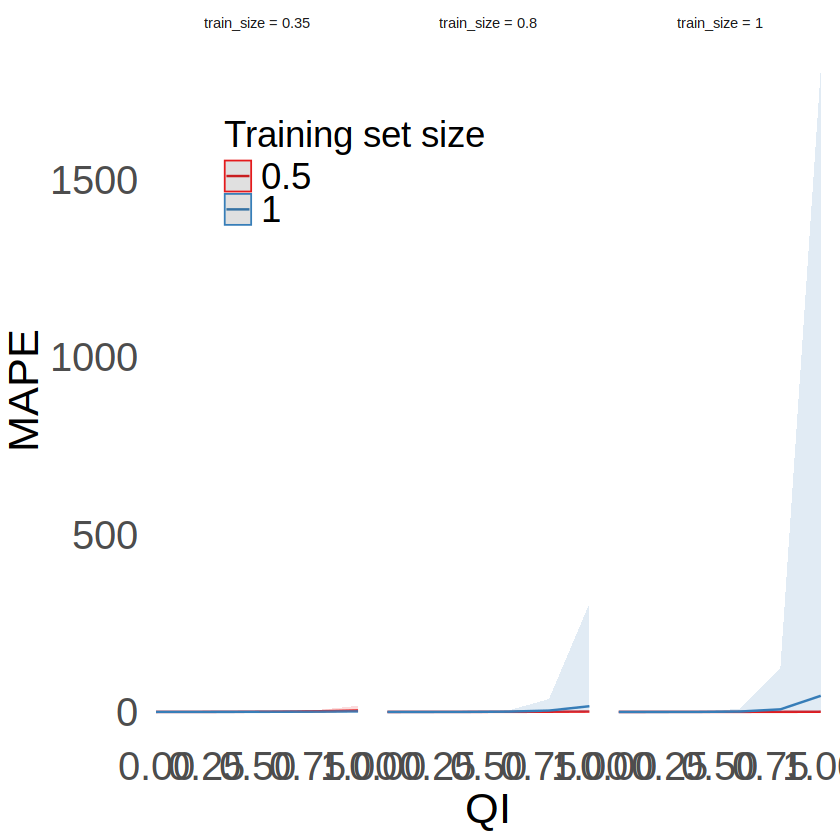

In [94]:
eff1 <- ggpredict(modelA_13, terms = c("qi", "qi_train [0.5, 1]", "train_size [0.35, 0.8, 1]"))
cha1 <- plot(eff1) +
  labs(
    title = NULL,  
    x = "QI",
    y = "MAPE",
    color = "Training set size"
  ) +
  theme_minimal() +
  theme(
    legend.position = "inside",  # Coordinates
    legend.position.inside = c(0.1, 0.9),  
    legend.justification = c("left", "top"),
    axis.title = element_text(size = 26),
    axis.text = element_text(size = 24),
    legend.text = element_text(size = 22),
    legend.title = element_text(size = 22),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank()
  )

cha1
ggsave(
  "output/mape_qi_x_train_size_effect.png",
  cha1,
  width = 12,
  height = 12,
  dpi = 600,
)

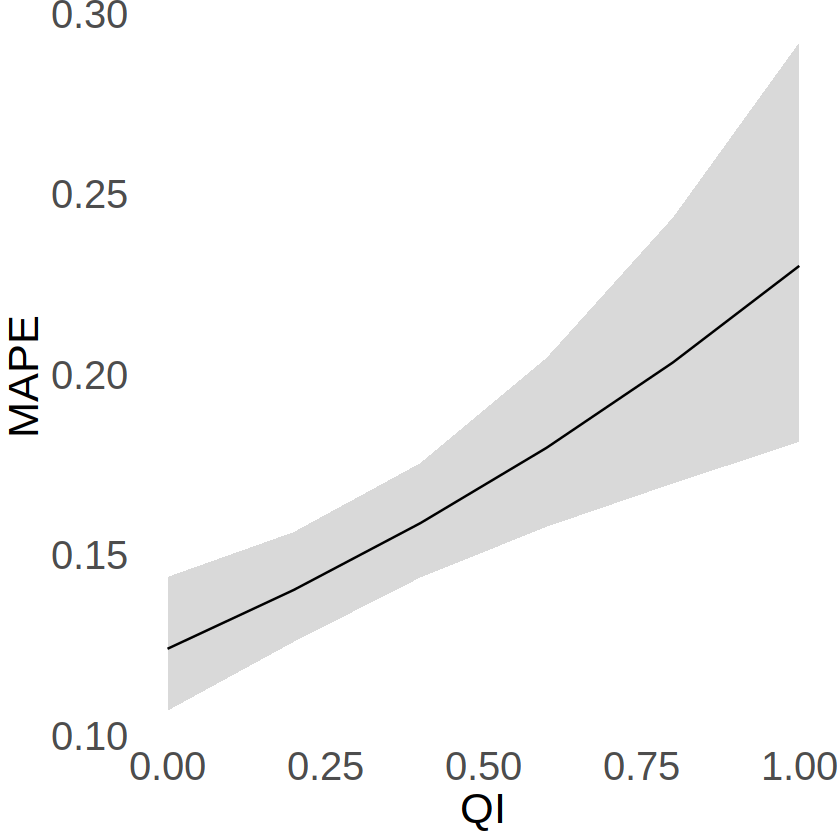

In [25]:
eff1 <- ggpredict(modelA_12, terms = c("qi"))
cha1 <- plot(eff1) +
  labs(
    title = NULL,  
    x = "QI",
    y = "MAPE",
    color = "Training set size"
  ) +
  theme_minimal() +
  theme(
    legend.position = "inside",  # Coordinates
    legend.position.inside = c(0.1, 0.9),  
    legend.justification = c("left", "top"),
    axis.title = element_text(size = 26),
    axis.text = element_text(size = 24),
    legend.text = element_text(size = 22),
    legend.title = element_text(size = 22),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank()
  )

cha1
ggsave(
  "output/mape_qi_effect.png",
  cha1,
  width = 12,
  height = 12,
  dpi = 600,
)

#### Weight

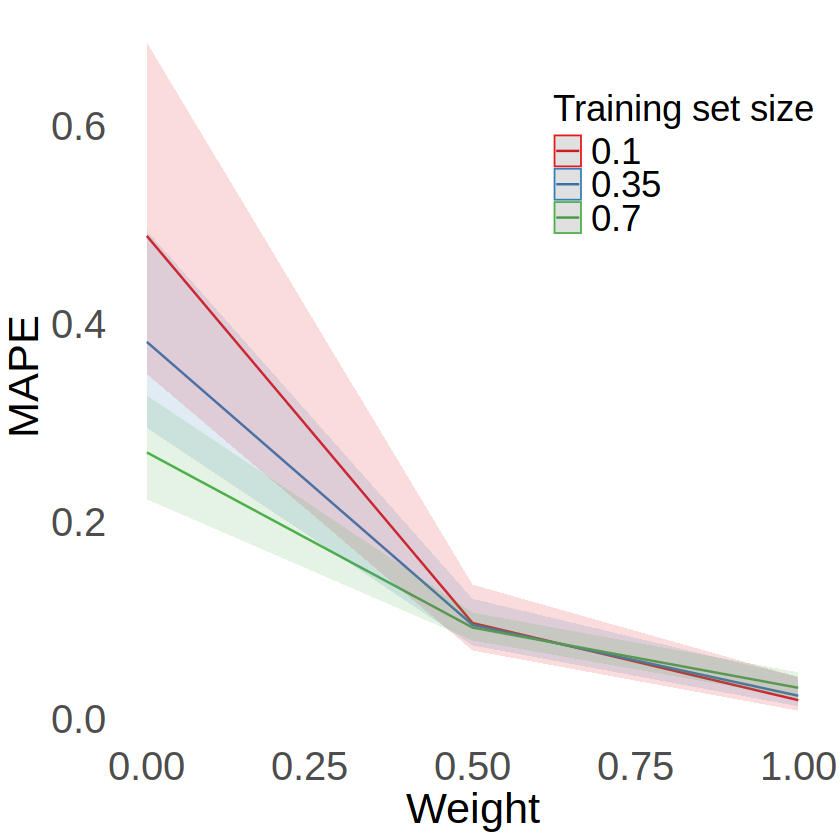

In [29]:
eff1 <- ggpredict(modelA_12, terms = c("weight", "train_size [0.35, 0.70, 0.1]"))
cha1 <- plot(eff1) +
  labs(
    title = NULL,  
    x = "Weight",
    y = "MAPE",
    color = "Training set size"
  ) +
  theme_minimal() +
  theme(
    legend.position = "inside",  # Coordinates
    legend.position.inside = c(0.6, 0.9),  
    legend.justification = c("left", "top"),
    axis.title = element_text(size = 26),
    axis.text = element_text(size = 24),
    legend.text = element_text(size = 22),
    legend.title = element_text(size = 22),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank()
  )

cha1
ggsave(
  "output/mape_wgt_x_train_size_effect.png",
  cha1,
  width = 12,
  height = 12,
  dpi = 600,
)

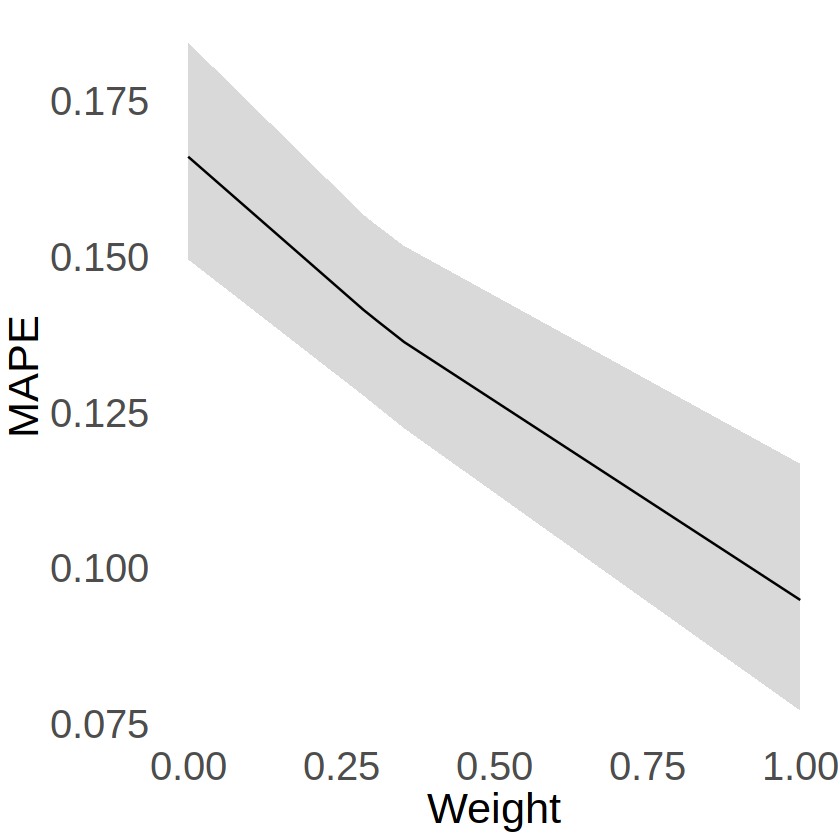

In [31]:
eff1 <- ggpredict(modelA_12, terms = c("qi_train"))
cha1 <- plot(eff1) +
  labs(
    title = NULL,  
    x = "Weight",
    y = "MAPE",
    color = "Training set size"
  ) +
  theme_minimal() +
  theme(
    legend.position = "inside",  # Coordinates
    legend.position.inside = c(0.6, 0.9),  
    legend.justification = c("left", "top"),
    axis.title = element_text(size = 26),
    axis.text = element_text(size = 24),
    legend.text = element_text(size = 22),
    legend.title = element_text(size = 22),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank()
  )

cha1
ggsave(
  "output/mape_wgt_effect.png",
  cha1,
  width = 12,
  height = 12,
  dpi = 600,
)

# Variability Analsysis

## Data Distribution

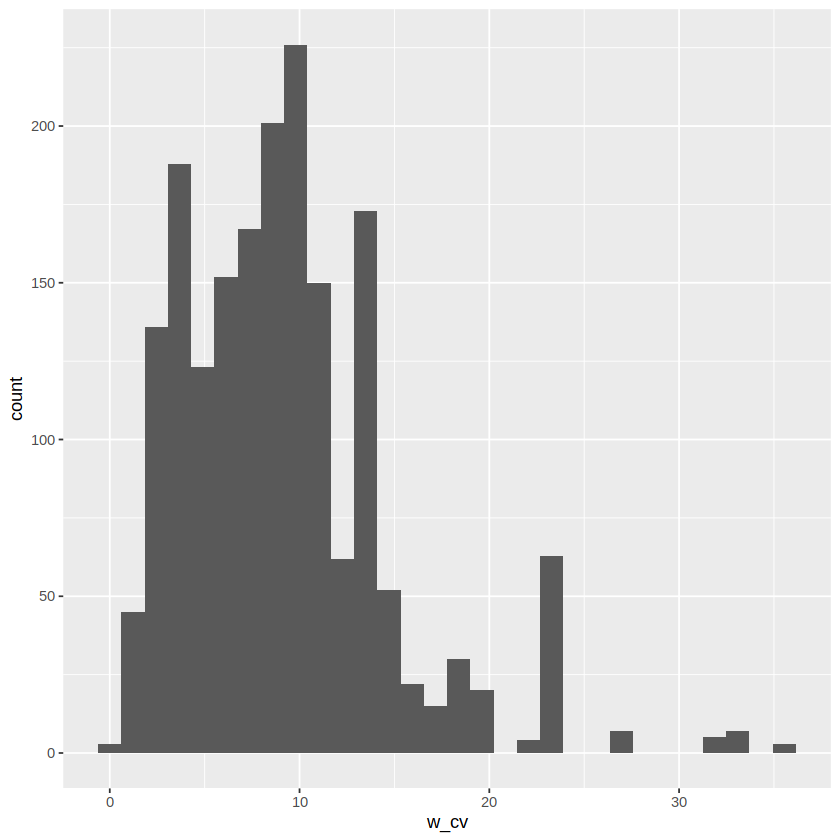

In [166]:
ggplot(dataset_v0, aes(x = w_cv)) + geom_histogram(bins = 30)

## Candidate Model #1

### Adjust Models

In [110]:
modelC_1 <- lme4::glmer(
  "w_cv ~ train_size + qi_train + qtt_in_train + qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_1)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train + qtt_in_train + qi + weight + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7917.2   7961.3  -3950.6   7901.2     1841 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9514 -0.2439 -0.0015  0.2433  4.0672 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.10383  0.3222  
 Residual             0.06628  0.2575  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
             Estimate Std. Error t value Pr(>|z|)    
(Intercept)   1.84154    0.16513  11.152  < 2e-16 ***
train_size    0.18810    0.06620   2.842  0.00449 ** 
qi_train      1.00247    0.03819  26.250  < 2e-16 ***
qtt_in_train  0.65796    0.11642   5.652 1.59e-08 ***
qi            0.09905    0.10651   0.930  0.35240    
weight       -2.09003    0.40165  -5.204 1.95e-07 ***
--

In [111]:
modelC_2 <- lme4::glmer(
  "w_cv ~ train_size * qi_train + qtt_in_train + qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_2)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.00299449 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi_train + qtt_in_train + qi + weight + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7879.9   7929.6  -3930.9   7861.9     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0409 -0.2039 -0.0017  0.2356  4.3747 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.10786  0.3284  
 Residual             0.06572  0.2564  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                    Estimate Std. Error t value Pr(>|z|)    
(Intercept)           2.4207     0.1922  12.595  < 2e-16 ***
train_size           -0.8772     0.1810  -4.846 1.26e-06 ***
qi_train              0.2973     0.1180   2.520   0.0117 *  
qtt_in_train          0.7716     0.1171   6.592 4.34e-11 ***
qi                    0.1153     0.1061   1.087   0.2770    
weight        

In [112]:
modelC_3 <- lme4::glmer(
  "w_cv ~ train_size + qi_train * qtt_in_train + qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_3)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train * qtt_in_train + qi + weight + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7827.5   7877.2  -3904.8   7809.5     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9942 -0.3152 -0.0014  0.3227  3.7524 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.10229  0.3198  
 Residual             0.06314  0.2513  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                      Estimate Std. Error t value Pr(>|z|)    
(Intercept)            2.20393    0.17042  12.932  < 2e-16 ***
train_size            -0.14004    0.07266  -1.927  0.05396 .  
qi_train               0.33008    0.07888   4.185 2.86e-05 ***
qtt_in_train           0.35688    0.11774   3.031  0.00244 ** 
qi                     0.10419    0.10442   0.998  0.31836    
we

In [113]:
modelC_4 <- lme4::glmer(
  "w_cv ~ train_size + qi_train * qtt_in_train * qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_4)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0322172 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train * qtt_in_train * qi + weight + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7742.9   7809.2  -3859.5   7718.9     1837 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0095 -0.2192 -0.0051  0.2268  3.9330 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.0981   0.3132  
 Residual             0.0603   0.2456  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                         Estimate Std. Error t value Pr(>|z|)    
(Intercept)               2.18008    0.18560  11.746  < 2e-16 ***
train_size               -0.12325    0.07355  -1.676  0.09379 .  
qi_train                  1.10596    0.22882   4.833 1.34e-06 ***
qtt_in_train              0.47194    0.19056   2.477  0.01327 *  
qi                       -0.04406    0.20980  -0.2

In [114]:
modelC_5 <- lme4::glmer(
  "w_cv ~ train_size + qi_train * qtt_in_train * weight + qi + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_5)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.842 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train * qtt_in_train * weight + qi + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7703.9   7770.2  -3840.0   7679.9     1837 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0206 -0.1713 -0.0054  0.2295  4.0751 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.11568  0.3401  
 Residual             0.05913  0.2432  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                             Estimate Std. Error t value Pr(>|z|)    
(Intercept)                    3.1022     0.2121  14.628  < 2e-16 ***
train_size                    -0.1516     0.1026  -1.478   0.1395    
qi_train                      -0.2296     0.1912  -1.200   0.2299    
qtt_in_train                  -0.9120     0.2314  -3.942 8.10e-05 ***
weight                        

In [115]:
modelC_6 <- lme4::glmer(
  "w_cv ~ train_size + qi_train * qi + qtt_in_train + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_6)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train * qi + qtt_in_train + weight + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7895.9   7945.6  -3938.9   7877.9     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0150 -0.2634 -0.0009  0.2403  4.2487 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.10292  0.3208  
 Residual             0.06547  0.2559  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
             Estimate Std. Error t value Pr(>|z|)    
(Intercept)   1.82914    0.16489  11.093  < 2e-16 ***
train_size    0.28791    0.06908   4.168 3.08e-05 ***
qi_train      0.49386    0.11176   4.419 9.92e-06 ***
qi           -0.05278    0.11002  -0.480    0.631    
qtt_in_train  0.71136    0.11660   6.101 1.05e-09 ***
weight       -2.07684    0.40122  -5.176 2.26e-07 ***
qi

In [116]:
modelC_7 <- lme4::glmer(
  "w_cv ~ train_size + qi_train * qi * weight + qtt_in_train + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_7)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.238974 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train * qi * weight + qtt_in_train + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7886.3   7952.5  -3931.1   7862.3     1837 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0317 -0.2606 -0.0051  0.2611  4.3481 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.09871  0.3142  
 Residual             0.06435  0.2537  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                   Estimate Std. Error t value Pr(>|z|)    
(Intercept)         1.99735    0.17608  11.344  < 2e-16 ***
train_size          0.43753    0.09420   4.645 3.41e-06 ***
qi_train           -0.07391    0.17974  -0.411  0.68092    
qi                 -0.24676    0.20062  -1.230  0.21869    
weight             -2.72227    0.46772  -5.820 5.87e-09 ***
qtt_in_train        

In [117]:
modelC_8 <- lme4::glmer(
  "w_cv ~ train_size + qi_train * weight + qi + qtt_in_train + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_8)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train * weight + qi + qtt_in_train + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7905.3   7955.0  -3943.6   7887.3     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9144 -0.2434 -0.0131  0.2377  4.1446 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.09364  0.3060  
 Residual             0.06491  0.2548  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                Estimate Std. Error t value Pr(>|z|)    
(Intercept)      1.97082    0.16048  12.281  < 2e-16 ***
train_size       0.44154    0.09268   4.764 1.90e-06 ***
qi_train         0.59783    0.11402   5.243 1.58e-07 ***
weight          -2.44359    0.39059  -6.256 3.95e-10 ***
qi               0.11105    0.10589   1.049 0.294299    
qtt_in_train     0.25310    0.15433   

In [118]:
modelC_9 <- lme4::glmer(
  "w_cv ~ train_size * qtt_in_train + qi_train + qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_9)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qtt_in_train + qi_train + qi + weight + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7881.4   7931.1  -3931.7   7863.4     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0005 -0.3441 -0.0087  0.3435  3.7368 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.10042  0.3169  
 Residual             0.06468  0.2543  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                        Estimate Std. Error t value Pr(>|z|)    
(Intercept)              2.22613    0.17485  12.732  < 2e-16 ***
train_size              -0.16668    0.08649  -1.927    0.054 .  
qtt_in_train            -0.25353    0.18709  -1.355    0.175    
qi_train                 0.81822    0.04824  16.960  < 2e-16 ***
qi                       0.09917    0.10548   0.940    

In [119]:
modelC_10 <- lme4::glmer(
  "w_cv ~ train_size * qtt_in_train * qi_train + qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_10)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 1.92506 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qtt_in_train * qi_train + qi + weight + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7700.7   7766.9  -3838.3   7676.7     1837 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9436 -0.2122 -0.0053  0.2159  4.0645 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.11422  0.3380  
 Residual             0.06113  0.2473  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                                 Estimate Std. Error t value Pr(>|z|)    
(Intercept)                        1.3092     0.3435   3.812 0.000138 ***
train_size                         0.6429     0.4304   1.494 0.135179    
qtt_in_train                       3.4936     0.5446   6.415 1.40e-10 ***
qi_train                           1.7116     0.3268   5.238 1.62e-07 ***
qi        

In [120]:
modelC_11 <- lme4::glmer(
  "w_cv ~ train_size * qtt_in_train * qi + qi_train + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_11)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.907159 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qtt_in_train * qi + qi_train + weight + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7746.9   7813.2  -3861.5   7722.9     1837 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0552 -0.2758 -0.0037  0.2561  4.0878 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.1027   0.3205  
 Residual             0.0599   0.2447  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                             Estimate Std. Error t value Pr(>|z|)    
(Intercept)                 2.2685409  0.2340333   9.693  < 2e-16 ***
train_size                 -0.2555505  0.1939644  -1.318   0.1877    
qtt_in_train                0.1232612  0.3329191   0.370   0.7112    
qi                          0.0005946  0.3250423   0.002   0.9985    
qi_train                    0.

In [121]:
modelC_12 <- lme4::glmer(
  "w_cv ~ train_size * qtt_in_train * weight + qi_train + qi + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_12)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.021988 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qtt_in_train * weight + qi_train + qi + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7703.3   7769.6  -3839.6   7679.3     1837 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0560 -0.2721 -0.0089  0.2832  3.9269 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.09413  0.3068  
 Residual             0.05862  0.2421  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                               Estimate Std. Error t value Pr(>|z|)    
(Intercept)                     2.41371    0.21094  11.443  < 2e-16 ***
train_size                      0.26234    0.16402   1.599  0.10973    
qtt_in_train                   -0.10873    0.39870  -0.273  0.78507    
weight                         -1.50583    0.68730  -2.191  0.02846 *  
qi_train            

In [122]:
modelC_13 <- lme4::glmer(
  "w_cv ~ train_size * qi + qtt_in_train + qi_train + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_13)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi + qtt_in_train + qi_train + weight + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7856.3   7906.0  -3919.2   7838.3     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0591 -0.2570 -0.0025  0.2538  4.4637 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.10244  0.3201  
 Residual             0.06459  0.2542  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
              Estimate Std. Error t value Pr(>|z|)    
(Intercept)    2.17095    0.16982  12.784  < 2e-16 ***
train_size    -0.30815    0.08949  -3.444 0.000574 ***
qi            -0.82974    0.15454  -5.369 7.92e-08 ***
qtt_in_train   0.72309    0.11429   6.327 2.50e-10 ***
qi_train       1.14319    0.04130  27.682  < 2e-16 ***
weight        -2.07827    0.40106  -5.182 2.20e-07

In [123]:
modelC_14 <- lme4::glmer(
  "w_cv ~ train_size * qi * weight + qtt_in_train + qi_train + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_14)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.657985 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi * weight + qtt_in_train + qi_train + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7854.6   7920.8  -3915.3   7830.6     1837 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0153 -0.2750 -0.0027  0.2597  4.4936 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.10154  0.3187  
 Residual             0.06544  0.2558  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                     Estimate Std. Error t value Pr(>|z|)    
(Intercept)           2.15653    0.18799  11.471  < 2e-16 ***
train_size           -0.35828    0.12246  -2.926 0.003438 ** 
qi                   -0.61677    0.27000  -2.284 0.022352 *  
weight               -2.09178    0.58571  -3.571 0.000355 ***
qtt_in_train          0.82484    0.12395   6.655 2.84e-11 ***
qi_train

In [124]:
modelC_15 <- lme4::glmer(
  "w_cv ~ train_size * weight + qtt_in_train + qi_train + qi + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelC_15)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * weight + qtt_in_train + qi_train + qi + (1 |  
    thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7894.6   7944.3  -3938.3   7876.6     1840 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.8933 -0.2692  0.0006  0.2556  4.2511 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.11044  0.3323  
 Residual             0.06627  0.2574  
Number of obs: 1849, groups:  thing_id, 143

Fixed effects:
                  Estimate Std. Error t value Pr(>|z|)    
(Intercept)        2.02862    0.17491  11.598  < 2e-16 ***
train_size        -0.21894    0.10522  -2.081   0.0375 *  
weight            -2.87115    0.44584  -6.440 1.20e-10 ***
qtt_in_train       0.84543    0.12351   6.845 7.64e-12 ***
qi_train           1.06904    0.04014  26.631  < 2e-16 ***
qi                 0.09587

## Candidate Model #2

### Adjust Models

In [131]:
modelD_1 <- lme4::glmer(
  "w_cv ~ train_size + qi_train + qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelD_1)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train + qi + weight + (1 | thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7950.5   7989.2  -3968.2   7936.5     1847 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9676 -0.1939 -0.0135  0.1922  3.9626 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.09004  0.3001  
 Residual             0.06599  0.2569  
Number of obs: 1854, groups:  thing_id, 144

Fixed effects:
            Estimate Std. Error t value Pr(>|z|)    
(Intercept)  2.02579    0.14419  14.050  < 2e-16 ***
train_size   0.49611    0.03891  12.751  < 2e-16 ***
qi_train     0.97016    0.03769  25.740  < 2e-16 ***
qi           0.11750    0.10661   1.102     0.27    
weight      -2.35146    0.33929  -6.930  4.2e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of 

In [132]:
modelD_2 <- lme4::glmer(
  "w_cv ~ train_size * qi_train + qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelD_2)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi_train + qi + weight + (1 | thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7924.6   7968.8  -3954.3   7908.6     1846 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0614 -0.1852 -0.0076  0.1898  4.2149 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.09039  0.3007  
 Residual             0.06532  0.2556  
Number of obs: 1854, groups:  thing_id, 144

Fixed effects:
                    Estimate Std. Error t value Pr(>|z|)    
(Intercept)           2.5359     0.1739  14.583  < 2e-16 ***
train_size           -0.3587     0.1659  -2.162  0.03060 *  
qi_train              0.3704     0.1192   3.108  0.00188 ** 
qi                    0.1387     0.1065   1.302  0.19280    
weight               -2.3363     0.3412  -6.847 7.52e-12 ***
train_size:qi_train   1.7116     0.

In [133]:
modelD_3 <- lme4::glmer(
  "w_cv ~ train_size * qi_train * qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelD_3)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.295092 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi_train * qi + weight + (1 | thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7899.5   7960.3  -3938.8   7877.5     1843 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9616 -0.1729 -0.0156  0.1872  4.3530 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.08650  0.2941  
 Residual             0.06469  0.2543  
Number of obs: 1854, groups:  thing_id, 144

Fixed effects:
                       Estimate Std. Error t value Pr(>|z|)    
(Intercept)             2.41576    0.23072  10.470  < 2e-16 ***
train_size             -0.01496    0.33629  -0.044 0.964513    
qi_train                1.12121    0.31353   3.576 0.000349 ***
qi                     -2.40586    0.81527  -2.951 0.003167 ** 
weight                 -2.40135    0.33172  -7.239 4.52e-13 ***
train_size:qi_tra

In [135]:
modelD_4 <- lme4::glmer(
  "w_cv ~ train_size * qi_train * weight + qi + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelD_4)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0401781 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi_train * weight + qi + (1 | thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7900.7   7961.5  -3939.4   7878.7     1843 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0024 -0.1921 -0.0098  0.1813  4.3073 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.08938  0.2990  
 Residual             0.06419  0.2534  
Number of obs: 1854, groups:  thing_id, 144

Fixed effects:
                           Estimate Std. Error t value Pr(>|z|)    
(Intercept)                 2.11976    0.24203   8.758  < 2e-16 ***
train_size                  0.43041    0.32187   1.337  0.18115    
qi_train                    0.61097    0.23352   2.616  0.00889 ** 
weight                     -1.26275    0.94556  -1.335  0.18173    
qi                          0.13693    0.10582   1.294  0.195

In [136]:
modelD_5 <- lme4::glmer(
  "w_cv ~ train_size * qi + weight + qi_train + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelD_5)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi + weight + qi_train + (1 | thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7898.7   7942.9  -3941.4   7882.7     1846 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0869 -0.1969 -0.0129  0.1919  4.3246 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.08723  0.2953  
 Residual             0.06426  0.2535  
Number of obs: 1854, groups:  thing_id, 144

Fixed effects:
              Estimate Std. Error t value Pr(>|z|)    
(Intercept)    2.35028    0.14901  15.772  < 2e-16 ***
train_size     0.06208    0.07014   0.885    0.376    
qi            -0.75968    0.15694  -4.840 1.30e-06 ***
weight        -2.35676    0.33518  -7.031 2.05e-12 ***
qi_train       1.09538    0.04067  26.933  < 2e-16 ***
train_size:qi  1.19120    0.16084   7.406 1.30e-13 ***
---
Signif. code

In [137]:
modelD_6 <- lme4::glmer(
  "w_cv ~ train_size * qi * weight + qi_train + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelD_6)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.00792106 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi * weight + qi_train + (1 | thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7903.7   7964.5  -3940.8   7881.7     1843 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0807 -0.2012 -0.0126  0.1951  4.3422 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.08725  0.2954  
 Residual             0.06421  0.2534  
Number of obs: 1854, groups:  thing_id, 144

Fixed effects:
                       Estimate Std. Error t value Pr(>|z|)    
(Intercept)           2.4243821  0.1722346  14.076  < 2e-16 ***
train_size            0.0005747  0.1090901   0.005   0.9958    
qi                   -0.8550288  0.2724218  -3.139   0.0017 ** 
weight               -2.7181807  0.5499765  -4.942 7.72e-07 ***
qi_train              1.0999516  0.0417635  26.338  < 2e-16 ***
train_size:qi    

In [138]:
modelD_7 <- lme4::glmer(
  "w_cv ~ train_size * weight + qi_train + qi + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelD_7)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * weight + qi_train + qi + (1 | thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7942.0   7986.2  -3963.0   7926.0     1846 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9434 -0.1840 -0.0115  0.1796  4.0729 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.0902   0.3003  
 Residual             0.0657   0.2563  
Number of obs: 1854, groups:  thing_id, 144

Fixed effects:
                  Estimate Std. Error t value Pr(>|z|)    
(Intercept)        2.17353    0.15160  14.338  < 2e-16 ***
train_size         0.29136    0.07430   3.922 8.79e-05 ***
weight            -2.87647    0.37695  -7.631 2.33e-14 ***
qi_train           1.01369    0.03995  25.376  < 2e-16 ***
qi                 0.12046    0.10645   1.132   0.2578    
train_size:weight  0.70294    0.21701   3.239  

In [140]:
modelD_8 <- lme4::glmer(
  "w_cv ~ train_size + qi_train * qi + weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelD_8)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train * qi + weight + (1 | thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7933.7   7977.9  -3958.8   7917.7     1846 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0446 -0.2207 -0.0082  0.2230  4.1207 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.08795  0.2966  
 Residual             0.06514  0.2552  
Number of obs: 1854, groups:  thing_id, 144

Fixed effects:
            Estimate Std. Error t value Pr(>|z|)    
(Intercept)  2.02908    0.14283  14.207  < 2e-16 ***
train_size   0.60703    0.04626  13.123  < 2e-16 ***
qi_train     0.51033    0.11222   4.548 5.42e-06 ***
qi          -0.01689    0.11000  -0.154    0.878    
weight      -2.36066    0.33584  -7.029 2.08e-12 ***
qi_train:qi  0.96772    0.22297   4.340 1.42e-05 ***
---
Signif. codes:  0 ‘***’ 0.

In [141]:
modelD_9 <- lme4::glmer(
  "w_cv ~ train_size + qi_train * qi * weight + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelD_9)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.267778 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train * qi * weight + (1 | thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7906.9   7967.7  -3942.4   7884.9     1843 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0352 -0.2418 -0.0029  0.2255  4.2626 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.08830  0.2972  
 Residual             0.06422  0.2534  
Number of obs: 1854, groups:  thing_id, 144

Fixed effects:
                   Estimate Std. Error t value Pr(>|z|)    
(Intercept)         2.11724    0.15599  13.573  < 2e-16 ***
train_size          0.67289    0.04716  14.268  < 2e-16 ***
qi_train           -0.11642    0.17274  -0.674  0.50034    
qi                 -0.19660    0.19950  -0.985  0.32439    
weight             -2.88361    0.41534  -6.943 3.85e-12 ***
qi_train:qi         1.54906    0.34928   

In [142]:
modelD_10 <- lme4::glmer(
  "w_cv ~ train_size + qi_train * weight + qi + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelD_10)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train * weight + qi + (1 | thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7921.4   7965.6  -3952.7   7905.4     1846 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9214 -0.2113 -0.0102  0.2094  4.0862 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.08925  0.2988  
 Residual             0.06495  0.2549  
Number of obs: 1854, groups:  thing_id, 144

Fixed effects:
                Estimate Std. Error t value Pr(>|z|)    
(Intercept)      2.03052    0.14419  14.082  < 2e-16 ***
train_size       0.57246    0.04066  14.078  < 2e-16 ***
qi_train         0.55822    0.08210   6.799 1.05e-11 ***
weight          -2.52467    0.34118  -7.400 1.36e-13 ***
qi               0.11789    0.10588   1.113    0.265    
qi_train:weight  1.17125    0.20902   5.603 2.10e-08 ***
--

In [143]:
modelD_11 <- lme4::glmer(
  "w_cv ~ train_size + qi_train + weight * qi + (1|thing_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelD_11)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train + weight * qi + (1 | thing_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
  7952.4   7996.6  -3968.2   7936.4     1846 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9696 -0.1936 -0.0135  0.1914  3.9634 

Random effects:
 Groups   Name        Variance Std.Dev.
 thing_id (Intercept) 0.08991  0.2999  
 Residual             0.06595  0.2568  
Number of obs: 1854, groups:  thing_id, 144

Fixed effects:
            Estimate Std. Error t value Pr(>|z|)    
(Intercept)  2.04326    0.15529  13.157  < 2e-16 ***
train_size   0.49619    0.03891  12.752  < 2e-16 ***
qi_train     0.97022    0.03769  25.741  < 2e-16 ***
weight      -2.41787    0.40442  -5.979 2.25e-09 ***
qi           0.06840    0.19514   0.351    0.726    
weight:qi    0.18675    0.62181   0.300    0.764    
---
Signif. codes:  0 ‘***’ 0.

### Model Effect

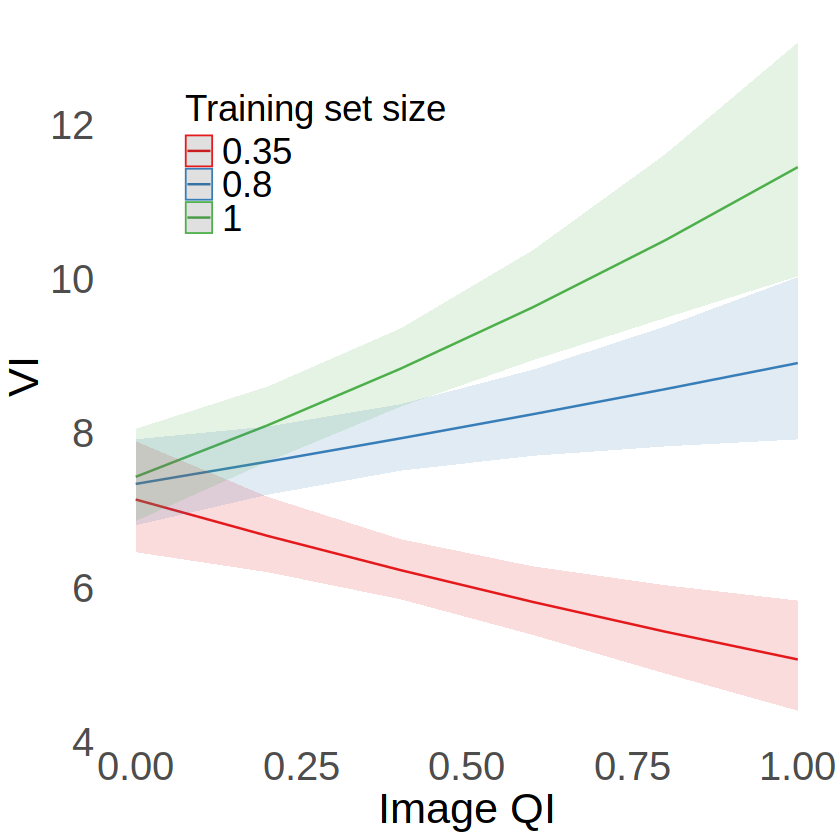

In [165]:
eff1 <- ggpredict(modelD_5, terms = c("qi", "train_size [0.35, 0.8, 1]"))
cha1 <- plot(eff1) +
  labs(
    title = NULL,  
    x = "Image QI",
    y = "VI",
    color = "Training set size"
  ) +
  theme_minimal() +
  theme(
    legend.position = "inside",  # Coordinates
    legend.position.inside = c(0.1, 0.9),  
    legend.justification = c("left", "top"),
    axis.title = element_text(size = 26),
    axis.text = element_text(size = 24),
    legend.text = element_text(size = 22),
    legend.title = element_text(size = 22),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank()
  )

cha1
ggsave(
  "output/vi_qi_x_train_size_effect.png",
  cha1,
  width = 12,
  height = 12,
  dpi = 600,
)